In [1]:
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import mokapot

import pyXLMS
from pyXLMS.data import create_csm
from pyXLMS.parser.util import format_sequence
from pyXLMS.parser.util import get_bool_from_value

from typing import List
from typing import Dict
from typing import Any

plt.style.use("seaborn-v0_8")

In [2]:
POSSIBLE_RESCORING_FEATURES = [
    "PG.Cscore",
    "EG.Cscore",
    "FG.Charge",
    "PG.Pvalue",
    "PG.PValue (Run-Wise)",
    "PG.Qvalue",
    "PG.QValue (Run-Wise)",
    "EG.GlobalPrecursorQvalue",
    "EG.MaxChannelQvalue",
    "EG.MinChannelQvalue",
    "EG.Qvalue",
    "EG.InSourceFragmentationParentQvalue",
    "EG.AvgProfileQvalue",
    "EG.MaxProfileQvalue",
    "EG.MinProfileQvalue",
    "EG.PercentileQvalue",
    "FG.Qvalue",
    "PP.MatchedIonsA",
    "PP.TotalIonsA",
    "PP.MatchedIonsB",
    "PP.TotalIonsB",
    "PP.RelativeMatchScoreA",
    "PP.RelativeMatchScoreB",
    "PP.PartialCscoreA",
    "PP.PartialCscoreB",
    "PP.CompositeRelativeMatchScore",
    "PP.CompositePartialCscore",
    "PP.SequenceCoverageNTermAlpha",
    "PP.SequenceCoverageNTermBeta",
    "PP.SequenceCoverageNTermFull",
    "PP.SequenceCoverageCTermAlpha",
    "PP.SequenceCoverageCTermBeta",
    "PP.SequenceCoverageCTermFull",
    "PP.SequenceCoverageAlpha",
    "PP.SequenceCoverageBeta",
    "PP.SequenceCoverageFull",
    "PP.UniScoreAlpha",
    "PP.UniScoreBeta",
    "PP.UniScoreFull",
    "PP.PepLenAlpha",
    "PP.PepLenBeta",
    "PP.NumberCrosslinkFragmentsAlpha",
    "PP.NumberCrosslinkFragmentsBeta",
    "PP.NumberCrosslinkFragmentsFull",
    "PP.NormalizedCrosslinkFragmentsAlpha",
    "PP.NormalizedCrosslinkFragmentsBeta",
    "PP.NormalizedCrosslinkFragmentsFull",
]
POSSIBLE_RESCORING_FEATURES_ALPHA = [
    "EG.Cscore",
    "PP.MatchedIonsA",
    "PP.TotalIonsA",
    "PP.RelativeMatchScoreA",
    "PP.PartialCscoreA",
    "PP.SequenceCoverageNTermAlpha",
    "PP.SequenceCoverageCTermAlpha",
    "PP.SequenceCoverageAlpha",
    "PP.UniScoreAlpha",
    "PP.PepLenAlpha",
    "PP.NumberCrosslinkFragmentsAlpha",
    "PP.NormalizedCrosslinkFragmentsAlpha",
]
POSSIBLE_RESCORING_FEATURES_BETA = [
    "EG.Cscore",
    "PP.MatchedIonsB",
    "PP.TotalIonsB",
    "PP.RelativeMatchScoreB",
    "PP.PartialCscoreB",
    "PP.SequenceCoverageNTermBeta",
    "PP.SequenceCoverageCTermBeta",
    "PP.SequenceCoverageBeta",
    "PP.UniScoreBeta",
    "PP.PepLenBeta",
    "PP.NumberCrosslinkFragmentsBeta",
    "PP.NormalizedCrosslinkFragmentsBeta",
]
assert len(POSSIBLE_RESCORING_FEATURES_ALPHA) == len(POSSIBLE_RESCORING_FEATURES_BETA)

In [3]:
def do_mokapot_columns(
    orig_df: pd.DataFrame, alpha: bool | None = None
) -> pd.DataFrame:
    df = orig_df.copy()
    df["MP.Spectrum"] = df.apply(
        lambda row: f"{row['R.FileName']}_{row['R.Condition']}_{row['PP.PseudoScanNumber']}",
        axis=1,
    )
    if alpha is None:
        df["MP.Target"] = df.apply(
            lambda row: not (
                get_bool_from_value(row["PP.IsDecoyA"])
                or get_bool_from_value(row["PP.IsDecoyB"])
            ),
            axis=1,
        )
        df["MP.Peptide"] = df.apply(
            lambda row: row["PP.PeptideA"] + row["PP.PeptideB"], axis=1
        )
        df["MP.Protein"] = df.apply(
            lambda row: ";".join(
                set(row["PP.ProteinA"].split(";")) | set(row["PP.ProteinB"].split(";"))
            ),
            axis=1,
        )
    elif alpha:
        df["MP.Target"] = df.apply(
            lambda row: not get_bool_from_value(row["PP.IsDecoyA"]), axis=1
        )
        df["MP.Peptide"] = df.apply(lambda row: row["PP.PeptideA"], axis=1)
        df["MP.Protein"] = df.apply(lambda row: row["PP.ProteinA"], axis=1)
    else:
        df["MP.Target"] = df.apply(
            lambda row: not get_bool_from_value(row["PP.IsDecoyB"]), axis=1
        )
        df["MP.Peptide"] = df.apply(lambda row: row["PP.PeptideB"], axis=1)
        df["MP.Protein"] = df.apply(lambda row: row["PP.ProteinB"], axis=1)
    df.dropna(axis=1, inplace=True)
    return df

## Rescoring CSMs

In [4]:
df = pd.read_csv(
    "data/THIDDIAXL003_DIAmethodEval_SN20c4_Report_FM_crosslinking_plusDecoy_req_DIA12_CV486075.csv_annotated.csv_grouped_by_residue_pair.csv",
    low_memory=False,
)

In [5]:
df = do_mokapot_columns(df)

In [6]:
rescoring_features = [
    feature for feature in POSSIBLE_RESCORING_FEATURES if feature in df
]

In [7]:
# https://mokapot.readthedocs.io/en/latest/api/dataset.html
psms = mokapot.dataset.LinearPsmDataset(
    psms=df,
    target_column="MP.Target",
    spectrum_columns="MP.Spectrum",
    peptide_column="MP.Peptide",
    protein_column="MP.Protein",
    feature_columns=rescoring_features,
    copy_data=True,
    rng=1337,
)

In [8]:
psms

A mokapot.dataset.LinearPsmDataset with 14492 PSMs:
	- Target PSMs: 3623
	- Decoy PSMs: 10869
	- Unique spectra: 14492
	- Unique peptides: 11398
	- Features: ('EG.Cscore', 'FG.Charge', 'PG.Pvalue', 'PG.PValue (Run-Wise)', 'PG.Qvalue', 'PG.QValue (Run-Wise)', 'PP.MatchedIonsA', 'PP.TotalIonsA', 'PP.MatchedIonsB', 'PP.TotalIonsB', 'PP.RelativeMatchScoreA', 'PP.RelativeMatchScoreB', 'PP.PartialCscoreA', 'PP.PartialCscoreB', 'PP.CompositeRelativeMatchScore', 'PP.CompositePartialCscore', 'PP.SequenceCoverageNTermAlpha', 'PP.SequenceCoverageNTermBeta', 'PP.SequenceCoverageNTermFull', 'PP.SequenceCoverageCTermAlpha', 'PP.SequenceCoverageCTermBeta', 'PP.SequenceCoverageCTermFull', 'PP.SequenceCoverageAlpha', 'PP.SequenceCoverageBeta', 'PP.SequenceCoverageFull', 'PP.UniScoreAlpha', 'PP.UniScoreBeta', 'PP.UniScoreFull', 'PP.PepLenAlpha', 'PP.PepLenBeta', 'PP.NumberCrosslinkFragmentsAlpha', 'PP.NumberCrosslinkFragmentsBeta', 'PP.NumberCrosslinkFragmentsFull', 'PP.NormalizedCrosslinkFragmentsAlpha

In [9]:
models, scores = mokapot.brew([psms])

Model training failed on 3/3. Setting scores to zero.
Learned model did not improve over the best feature. Now scoring by the best feature for each collection of PSMs.


In [10]:
df["Mokapot Score"] = scores[0]

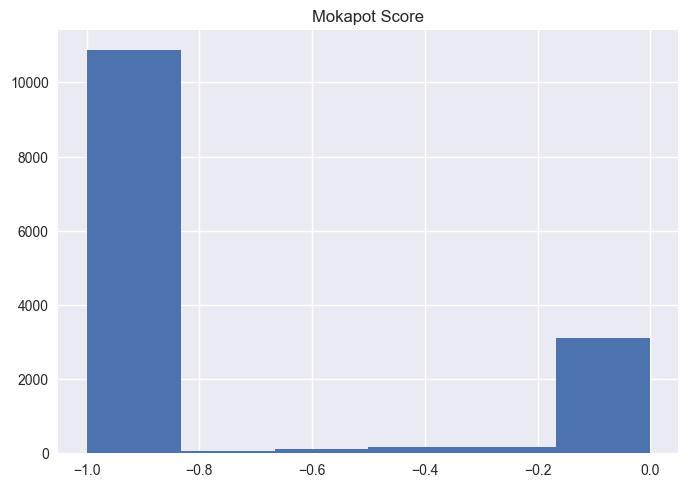

In [11]:
df.hist("Mokapot Score", bins=6);

In [12]:
conf = mokapot.confidence.assign_confidence([psms], scores)

C:\Users\P42587\Documents\GitHub\MSAnnika_Spectral_Library_exporter_rescoring\.venv\Lib\site-packages\mokapot\tabular_data\csv.py:107: UserWarning: CSV file targets.psms.csv exists, but will be overwritten.
  warnings.warn(
C:\Users\P42587\Documents\GitHub\MSAnnika_Spectral_Library_exporter_rescoring\.venv\Lib\site-packages\mokapot\tabular_data\csv.py:107: UserWarning: CSV file targets.mp.peptides.csv exists, but will be overwritten.
  warnings.warn(
C:\Users\P42587\Documents\GitHub\MSAnnika_Spectral_Library_exporter_rescoring\.venv\Lib\site-packages\triqler\qvality.py:267: RuntimeWarning: overflow encountered in dot
  M = R + Q.T.dot(aWiQ)
C:\Users\P42587\Documents\GitHub\MSAnnika_Spectral_Library_exporter_rescoring\.venv\Lib\site-packages\triqler\qvality.py:267: RuntimeWarning: overflow encountered in dot
  M = R + Q.T.dot(aWiQ)


In [13]:
psms_conf: pd.DataFrame = conf[0].psms
print(
    f"Target hits with q-value < 0.01: {psms_conf[psms_conf['mokapot_qvalue'] < 0.01].shape[0]}"
)

Target hits with q-value < 0.01: 3623


In [14]:
def read_csms(
    df: pd.DataFrame,
) -> List[Dict[str, Any]]:
    csms = list()
    for i, row in tqdm(df.iterrows(), total=df.shape[0], desc="Reading CSMs..."):
        score_a = None
        score_b = None
        score_csm = float(row["Mokapot Score"])
        csm = create_csm(
            peptide_a=format_sequence(row["PP.PeptideA"]),
            modifications_a=None,
            xl_position_peptide_a=int(row["PP.CrosslinkPositionPeptideA"]),
            proteins_a=str(row["PP.ProteinA"]).split(";"),
            xl_position_proteins_a=[
                int(pos) for pos in str(row["PP.CrosslinkPositionProteinA"]).split(";")
            ],
            pep_position_proteins_a=[
                int(pos) for pos in str(row["PP.PeptidePositionProteinA"]).split(";")
            ],
            score_a=score_a,
            decoy_a=get_bool_from_value(row["PP.IsDecoyA"]),
            peptide_b=format_sequence(row["PP.PeptideB"]),
            modifications_b=None,
            xl_position_peptide_b=int(row["PP.CrosslinkPositionPeptideB"]),
            proteins_b=str(row["PP.ProteinB"]).split(";"),
            xl_position_proteins_b=[
                int(pos) for pos in str(row["PP.CrosslinkPositionProteinB"]).split(";")
            ],
            pep_position_proteins_b=[
                int(pos) for pos in str(row["PP.PeptidePositionProteinB"]).split(";")
            ],
            score_b=score_b,
            decoy_b=get_bool_from_value(row["PP.IsDecoyB"]),
            score=score_csm,
            spectrum_file=f"{row['R.Condition'].strip()}:{row['R.FileName'].strip()}",
            scan_nr=int(row["PP.PseudoScanNumber"]),
            charge=int(row["FG.Charge"]),
            rt=None,
            im_cv=None,
        )
        csms.append(csm)
    return csms


def pipeline(csms: List[Dict[str, Any]], fdr=0.01) -> List[Dict[str, Any]]:
    u = pyXLMS.transform.unique(csms)
    v = pyXLMS.transform.validate(u, fdr=fdr)
    t = pyXLMS.transform.targets_only(v)
    return t

In [15]:
csms = read_csms(df)

Reading CSMs...: 100%|█████████████████████████████████████████████████████████| 14492/14492 [00:01<00:00, 9023.52it/s]


In [16]:
validated_targets = pipeline(csms)

Iterating over scores for FDR calculation...:  75%|████████████████████▎      | 10869/14492 [00:00<00:00, 31646.39it/s]


In [17]:
print(f"Target hits at 1% estimated FDR: {len(validated_targets)}")

Target hits at 1% estimated FDR: 3623


## Rescoring PSMs

In [18]:
df = pd.read_csv(
    "data/THIDDIAXL003_DIAmethodEval_SN20c4_Report_FM_crosslinking_plusDecoy_req_DIA12_CV486075.csv_annotated.csv_grouped_by_residue_pair.csv",
    low_memory=False,
)
df_alpha = pd.read_csv(
    "data/THIDDIAXL003_DIAmethodEval_SN20c4_Report_FM_crosslinking_plusDecoy_req_DIA12_CV486075.csv_annotated.csv_grouped_by_residue_pair.csv",
    low_memory=False,
)
df_beta = pd.read_csv(
    "data/THIDDIAXL003_DIAmethodEval_SN20c4_Report_FM_crosslinking_plusDecoy_req_DIA12_CV486075.csv_annotated.csv_grouped_by_residue_pair.csv",
    low_memory=False,
)

In [19]:
df_alpha = do_mokapot_columns(df_alpha, alpha=True)
df_beta = do_mokapot_columns(df_beta, alpha=False)

In [20]:
rescoring_features_alpha = [
    feature for feature in POSSIBLE_RESCORING_FEATURES_ALPHA if feature in df
]
rescoring_features_beta = [
    feature for feature in POSSIBLE_RESCORING_FEATURES_BETA if feature in df
]

In [21]:
psms_alpha = mokapot.dataset.LinearPsmDataset(
    psms=df_alpha,
    target_column="MP.Target",
    spectrum_columns="MP.Spectrum",
    peptide_column="MP.Peptide",
    protein_column="MP.Protein",
    feature_columns=rescoring_features_alpha,
    copy_data=True,
    rng=1337,
)

In [22]:
psms_alpha

A mokapot.dataset.LinearPsmDataset with 14492 PSMs:
	- Target PSMs: 7246
	- Decoy PSMs: 7246
	- Unique spectra: 14492
	- Unique peptides: 338
	- Features: ('EG.Cscore', 'PP.MatchedIonsA', 'PP.TotalIonsA', 'PP.RelativeMatchScoreA', 'PP.PartialCscoreA', 'PP.SequenceCoverageNTermAlpha', 'PP.SequenceCoverageCTermAlpha', 'PP.SequenceCoverageAlpha', 'PP.UniScoreAlpha', 'PP.PepLenAlpha', 'PP.NumberCrosslinkFragmentsAlpha', 'PP.NormalizedCrosslinkFragmentsAlpha')

In [23]:
psms_beta = mokapot.dataset.LinearPsmDataset(
    psms=df_beta,
    target_column="MP.Target",
    spectrum_columns="MP.Spectrum",
    peptide_column="MP.Peptide",
    protein_column="MP.Protein",
    feature_columns=rescoring_features_beta,
    copy_data=True,
    rng=1337,
)

In [24]:
psms_beta

A mokapot.dataset.LinearPsmDataset with 14492 PSMs:
	- Target PSMs: 7246
	- Decoy PSMs: 7246
	- Unique spectra: 14492
	- Unique peptides: 330
	- Features: ('EG.Cscore', 'PP.MatchedIonsB', 'PP.TotalIonsB', 'PP.RelativeMatchScoreB', 'PP.PartialCscoreB', 'PP.SequenceCoverageNTermBeta', 'PP.SequenceCoverageCTermBeta', 'PP.SequenceCoverageBeta', 'PP.UniScoreBeta', 'PP.PepLenBeta', 'PP.NumberCrosslinkFragmentsBeta', 'PP.NormalizedCrosslinkFragmentsBeta')

In [25]:
models_alpha, scores_alpha = mokapot.brew([psms_alpha])

C:\Users\P42587\Documents\GitHub\MSAnnika_Spectral_Library_exporter_rescoring\.venv\Lib\site-packages\mokapot\brew.py:462: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  psms_chunk["fold"] = model_test_idx.pop(0)


In [26]:
models_beta, scores_beta = mokapot.brew([psms_beta])

C:\Users\P42587\Documents\GitHub\MSAnnika_Spectral_Library_exporter_rescoring\.venv\Lib\site-packages\mokapot\brew.py:462: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  psms_chunk["fold"] = model_test_idx.pop(0)


In [27]:
df["Mokapot Score Alpha"] = scores_alpha[0]
df["Mokapot Score Beta"] = scores_beta[0]
df["Mokapot Score"] = df.apply(
    lambda row: min(row["Mokapot Score Alpha"], row["Mokapot Score Beta"]), axis=1
)

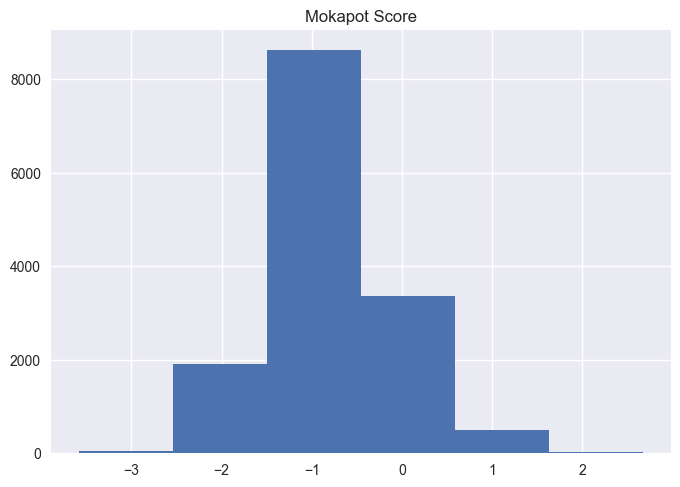

In [28]:
df.hist("Mokapot Score", bins=6);

In [29]:
csms = read_csms(df)

Reading CSMs...: 100%|█████████████████████████████████████████████████████████| 14492/14492 [00:01<00:00, 8280.87it/s]


In [30]:
validated_targets = pipeline(csms)

Iterating over scores for FDR calculation...:  89%|███████████████████████▉   | 12849/14492 [00:00<00:00, 44546.56it/s]


In [31]:
print(f"Target hits at 1% estimated FDR: {len(validated_targets)}")

Target hits at 1% estimated FDR: 1627


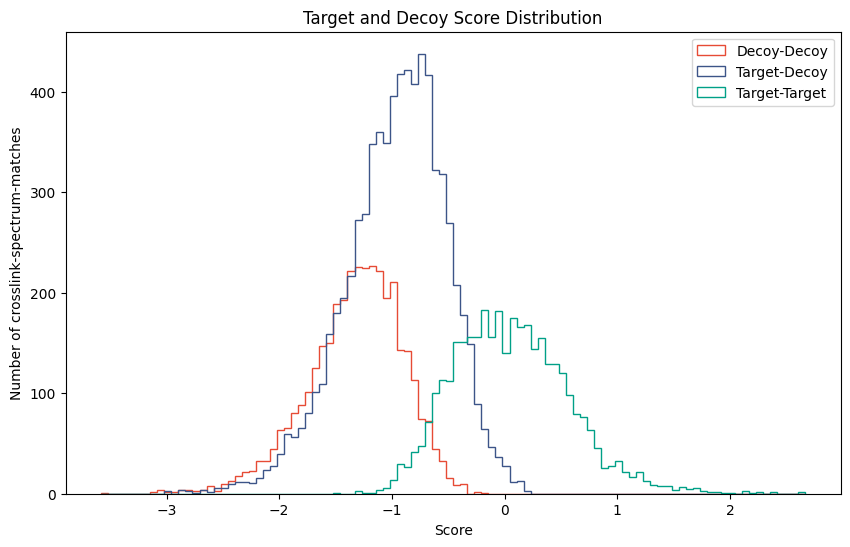

In [32]:
plt.style.use("default")

pyXLMS.plotting.plot_score_distribution(csms, bins=100, figsize=(10, 6));

In [33]:
df.to_csv(
    "mokapot/THIDDIAXL003_DIAmethodEval_SN20c4_Report_FM_crosslinking_plusDecoy_req_DIA12_CV486075.csv_annotated.csv_grouped_by_residue_pair.csv",
    index=False,
)